# 信用卡欺诈检测 — 项目分析 Notebook

> 独立于 Kaggle kernel，用于行业背景验证、EDA、特征工程、建模与后续实验。

**工作计划对照：**
- [x] Todo #1 行业背景调研与假设验证
- [x] Todo #2 基线模型与难样本分析
- [ ] Todo #3 欺诈样本特征画像
- [ ] Todo #4 阈值调优 & scale_pos_weight 实验（logloss）
- [ ] Todo #5 基线模型优化（CV / 调参 / 融合）
- [ ] Todo #6 特征工程（定稿）→ 详见 [`credit-fraud-feature-engineering-1.ipynb`](credit-fraud-feature-engineering-1.ipynb)
- [ ] Todo #7 SHAP 可解释性

详细调研笔记见 `行业背景调研笔记.md`。


## 0. 环境与数据加载


In [1]:
# --- 0. 环境与数据加载 ---
# 先屏蔽无关警告，导入 EDA 常用库；读入 Kaggle creditcard.csv 并记录全局欺诈率 FRAUD_RATE，
# 后续各节都用它做 lift / 对照基线。
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 35)


def setup_matplotlib_cjk() -> bool:
    """注册系统中文字体；matplotlib 默认字体不含中文时会显示方框。"""
    plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
    for font_path in (
        '/System/Library/Fonts/STHeiti Medium.ttc',
        '/System/Library/Fonts/STHeiti Light.ttc',
        '/System/Library/Fonts/Supplemental/Arial Unicode.ttf',
        '/Library/Fonts/Arial Unicode.ttf',
    ):
        if os.path.isfile(font_path):
            font_manager.fontManager.addfont(font_path)
            family = font_manager.FontProperties(fname=font_path).get_name()
            plt.rcParams['font.family'] = 'sans-serif'
            plt.rcParams['font.sans-serif'] = [family, 'DejaVu Sans']
            return True
    for family in ('Heiti SC', 'STHeiti', 'Arial Unicode MS', 'PingFang SC', 'Hiragino Sans GB'):
        if family in {f.name for f in font_manager.fontManager.ttflist}:
            plt.rcParams['font.sans-serif'] = [family, 'DejaVu Sans']
            return True
    return False


USE_CJK_FONTS = setup_matplotlib_cjk()

# 图表标签：有中文字体用中文，否则英文（中文含义见 else 分支注释）
if USE_CJK_FONTS:
    PLOT_LBL = dict(
        normal='正常', fraud='欺诈',
        amount_dist='交易额分布 (0–500 欧元)', amount_x='交易额 (欧元)',
        log_amount_dist='log1p(交易额) 分布', log_amount_x='log1p(交易额)',
        density='概率密度', baseline='全表基线', fraud_rate='欺诈率',
        hours_x='距首笔交易的小时数', hour_fraud_title='各相对小时的欺诈率',
    )
else:
    PLOT_LBL = dict(
        normal='Normal', fraud='Fraud',  # 正常, 欺诈
        amount_dist='Amount distribution (0–500 EUR)',  # 交易额分布
        amount_x='Amount (EUR)',  # 交易额
        log_amount_dist='log1p(Amount) distribution',  # log1p(交易额) 分布
        log_amount_x='log1p(Amount)',  # log1p(交易额)
        density='Density',  # 概率密度
        baseline='Overall baseline',  # 全表基线
        fraud_rate='Fraud rate',  # 欺诈率
        hours_x='Hours since first transaction',  # 距首笔交易的小时数
        hour_fraud_title='Fraud rate by relative hour',  # 各相对小时的欺诈率
    )
    print('提示：未找到可用中文字体，图表标签已改用英文。')

def resolve_creditcard_path() -> Path:
    """自 cwd 向上查找项目根下的 input/creditcard.csv（兼容 src/ 与 src/feature-engineering/）。"""
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / 'input' / 'creditcard.csv'
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        '未找到 input/creditcard.csv；请在项目根或 src/feature-engineering 下运行 notebook。'
    )


DATA_PATH = resolve_creditcard_path()


def read_creditcard_csv(path) -> pd.DataFrame:
    """依次尝试 utf-8 / 容错 utf-8 / latin-1，避免 UnicodeDecodeError 卡死。"""
    for kwargs in (
        {'encoding': 'utf-8'},
        {'encoding': 'utf-8', 'encoding_errors': 'replace'},
        {'encoding': 'latin-1'},
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, 'failed to decode creditcard.csv with utf-8/latin-1')

df = read_creditcard_csv(DATA_PATH)

FRAUD_RATE = df['Class'].mean()  # 全表欺诈占比，作为各假设检验的基准线
print(f'行数: {len(df):,}  |  欺诈笔数: {df["Class"].sum()}  |  欺诈率: {FRAUD_RATE:.4f}')


行数: 284,807  |  欺诈笔数: 492  |  欺诈率: 0.0017


## 1. Todo #1 — 行业假设验证（EDA）

基于行业背景，对以下假设做统计验证。


### 1.1 假设：欺诈与正常的 Amount 分布不同


,正常,欺诈
样本数,284315.00,492.00
均值,88.29,122.21
标准差,250.11,256.68
最小值,0.00,0.00
25%分位,5.65,1.00
中位数,22.00,9.25
75%分位,77.05,105.89
最大值,25691.16,2125.87


KS 检验: 统计量=0.2712, p=2.17e-32


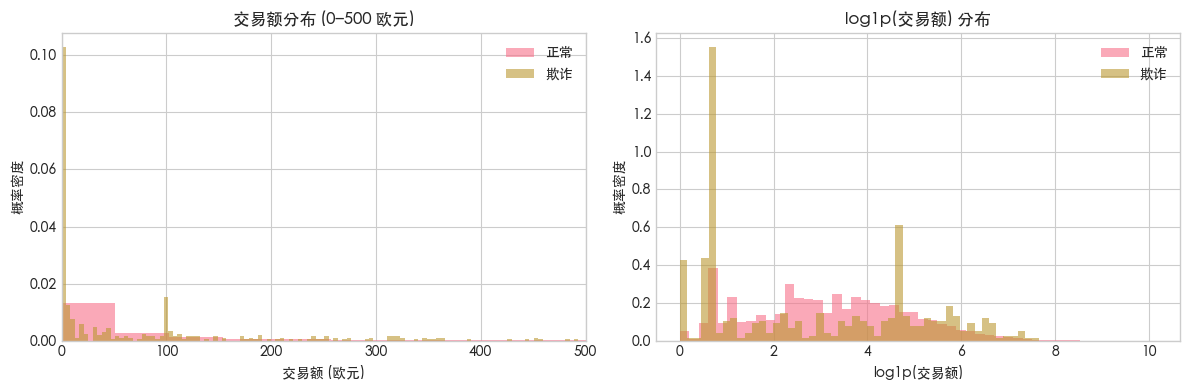

In [2]:
# --- 1.1 Amount 分布对比 ---
# 行业上欺诈金额常与正常不同（卡测试偏小额、盗刷可能偏大额）。
# 用 describe 看位置/离散度，KS 检验两总体是否同分布，再画原尺度与 log1p 尺度直方图。
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

DESCRIBE_CN = {
    'count': '样本数', 'mean': '均值', 'std': '标准差', 'min': '最小值',
    '25%': '25%分位', '50%': '中位数', '75%': '75%分位', 'max': '最大值',
}
stats_table = pd.DataFrame({
    '正常': normal['Amount'].describe(),
    '欺诈': fraud['Amount'].describe(),
}).round(2).rename(index=DESCRIBE_CN)
display(stats_table)

ks_stat, ks_p = stats.ks_2samp(normal['Amount'], fraud['Amount'])
print(f'KS 检验: 统计量={ks_stat:.4f}, p={ks_p:.2e}')

# 只看概率密度
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(normal['Amount'], bins=500, alpha=0.6, label=PLOT_LBL['normal'], density=True)
axes[0].hist(fraud['Amount'], bins=500, alpha=0.6, label=PLOT_LBL['fraud'], density=True)
axes[0].set_xlim(0, 500)  # 截断到 500 EUR，避免长尾压扁小额区
axes[0].set_title(PLOT_LBL['amount_dist'])  # 交易额分布 (0–500 欧元)
axes[0].set_xlabel(PLOT_LBL['amount_x'])  # 交易额 (欧元)
axes[0].set_ylabel(PLOT_LBL['density'])  # 概率密度
axes[0].legend()

axes[1].hist(np.log1p(normal['Amount']), bins=50, alpha=0.6, label=PLOT_LBL['normal'], density=True)
axes[1].hist(np.log1p(fraud['Amount']), bins=50, alpha=0.6, label=PLOT_LBL['fraud'], density=True)
axes[1].set_title(PLOT_LBL['log_amount_dist'])  # log1p(交易额) 分布
axes[1].set_xlabel(PLOT_LBL['log_amount_x'])  # log1p(交易额)
axes[1].set_ylabel(PLOT_LBL['density'])  # 概率密度
axes[1].legend()
plt.tight_layout()
plt.show()


柱子高度 = 落在这个区间的样本比例/这个区间的宽度

可以看出小额卡测试样本占诈骗总样本比例很大。**交易额是否为特定的小额范围** 值得作为单独研究的特征

### 1.2 假设：欺诈更集中在小额（卡测试 Card Testing）


In [3]:
# 对每个金额阈值 t，看「金额 < t」在欺诈/正常中各占百分之几。
THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.01, 1.05, 1.1, 1.25, 1.5, 2, 3, 5, 10, 15, 17.5, 19, 20, 25]
rows = []
for t in THRESHOLDS:
    rows.append({
        '阈值(欧元)': t,
        '正常占比(%)': (normal['Amount'] < t).mean() * 100,
        '欺诈占比(%)': (fraud['Amount'] < t).mean() * 100,  # 当前交易额覆盖了占比多少的欺诈样本
    })
small_df = pd.DataFrame(rows)
small_df['欺诈/正常倍数'] = small_df['欺诈占比(%)'] / small_df['正常占比(%)']
display(small_df.round(2))


,阈值(欧元),正常占比(%),欺诈占比(%),欺诈/正常倍数
0,0.10,0.94,6.50,6.90
1,0.20,1.06,6.50,6.14
2,0.30,1.11,6.71,6.06
3,0.40,1.14,6.91,6.08
4,0.50,1.18,6.91,5.83
5,0.60,1.22,6.91,5.68
6,0.70,1.34,7.72,5.78
7,0.80,3.10,13.21,4.26
8,0.90,4.89,13.62,2.78
9,1.00,5.89,13.82,2.35


可以考虑建立以下 **bool** 特征：  
`is_micro_testing` (Amount ≤ 1.05 EUR)：超级小额带。  
`is_small_testing` (1.05 < Amount ≤ 5 EUR)：次高危小额带。  
`is_normal_small` (5 < Amount < 20 EUR)：欺诈与正常开始混淆的模糊带。  
`is_one_euro` (Amount == 1.0)：约 23% 欺诈集中于此。  
这些指标都有待验证（累积阈值不能完全体现问题）。  
**危险度这种指标我很怀疑它的效果，手算的危险度指标不管怎么设计很难和欺诈完全拟合，既然有区别那就是在人为制造噪声，不如只摆事实引导树模型自己学。**  
这些特征 **保持独立、不合而为一**，虽然信息量上等效，但或许可以给树模型更多分裂机会。  
中大额是否追加 特征 见 **1.2b** lift 与 **Section 5 ablation**。


### 1.2b 金额区间 lift 与 1 欧尖峰（决定是否追加事实 bool）
lift：这个金额区间里，欺诈是不是比「全表平均水平」更集中？集中多少倍？  

In [4]:
# --- 1.2b 区间 lift + 1 欧尖峰 ---
n_fraud, n_normal = len(fraud), len(normal)

# 1 欧尖峰：精确 Amount==1.0（数据中无 (1.0,1.01] 粒度）
one_euro_f = (fraud['Amount'] == 1.0).sum()
one_euro_n = (normal['Amount'] == 1.0).sum()
lift_one = (one_euro_f / n_fraud) / (one_euro_n / n_normal)
print(f'Amount==1.0: 欺诈 {one_euro_f} 笔 ({one_euro_f/n_fraud*100:.1f}% 欺诈), '
      f'正常 {one_euro_n:,} 笔, lift={lift_one:.2f}')

AMOUNT_BINS = [
    ('micro (<1)', lambda d: d['Amount'] < 1),
    # ('micro (≤1.05)', lambda d: d['Amount'] <= 1.05),
    ('small (1–5]', lambda d: (d['Amount'] > 1) & (d['Amount'] <= 5)),
    ('normal_small (5–20)', lambda d: (d['Amount'] > 5) & (d['Amount'] < 20)),
    ('mid (20–100]', lambda d: (d['Amount'] >= 20) & (d['Amount'] <= 100)),
    ('mid_high (100–500]', lambda d: (d['Amount'] > 100) & (d['Amount'] <= 500)),
    ('high (500–2000]', lambda d: (d['Amount'] > 500) & (d['Amount'] <= 2000)),
    ('very_high (>2000)', lambda d: d['Amount'] > 2000),
]
lift_rows = []
for label, fn in AMOUNT_BINS:
    fc = int(fn(fraud).sum())
    nc = int(fn(normal).sum())
    lift = (fc / n_fraud) / (nc / n_normal) if nc else np.nan
    lift_rows.append({
        '区间': label, '欺诈笔数': fc, '欺诈占比(%)': fc / n_fraud * 100,
        '正常笔数': nc, 'lift': lift,
    })
lift_df = pd.DataFrame(lift_rows)
display(lift_df.round(4))

# 中大额数据概况
EXT_THRESHOLDS = [25, 50, 100, 250, 500, 1000, 5000]
ext_rows = []
for t in EXT_THRESHOLDS:
    ext_rows.append({
        '阈值(欧元)': t,
        '欺诈占比(%)': (fraud['Amount'] < t).mean() * 100,
        '正常占比(%)': (normal['Amount'] < t).mean() * 100,
    })
ext_df = pd.DataFrame(ext_rows)
ext_df['欺诈/正常倍数'] = ext_df['欺诈占比(%)'] / ext_df['正常占比(%)']
print('累积阈值（20 EUR 以上粗看）:')
display(ext_df.round(2))


Amount==1.0: 欺诈 113 笔 (23.0% 欺诈), 正常 13,575 笔, lift=4.81


,区间,欺诈笔数,欺诈占比(%),正常笔数,lift
0,micro (<1),68,13.8211,16736,2.3480
1,small (1–5],41,8.3333,38499,0.6154
2,normal_small (5–20),49,9.9593,68047,0.4161
3,mid (20–100],91,18.4959,91080,0.5774
4,mid_high (100–500],95,19.3089,47271,1.1614
5,high (500–2000],34,6.9106,8432,2.3301
6,very_high (>2000),1,0.2033,675,0.8561


累积阈值（20 EUR 以上粗看）:


,阈值(欧元),欺诈占比(%),正常占比(%),欺诈/正常倍数
0,25,55.89,52.30,1.07
1,50,61.99,66.62,0.93
2,100,73.58,79.86,0.92
3,250,84.96,91.97,0.92
4,500,92.89,96.67,0.96
5,1000,98.17,98.92,0.99
6,5000,100.00,99.98,1.00


**1.2b 结论（事实 bool 决策，无危险度分数）：**
- 保留 `is_one_euro`（`Amount == 1.0`）：约 23% 欺诈集中于此，lift ~4.8
- `is_micro_testing` 改为 Amount < 1 EUR：超小额带
- `is_small_testing` 和 `is_normal_small` 合并为 `is_small_testing`，对应(1 <= Amount ≤ 20 EUR)的卡测试行为
- 中额度区间诈骗行为并不高发，或可作为一个负相关指标（有必要吗？树也可以自己切分。暂不做）
- `high (500-2000] EUR` lift ~2.2 → 或可产生一个大额的指标（如没有更好办法）
- 或许考虑增加一个log1p(Amount)指标照顾大额数据长尾效应


### 1.3 假设：深夜/非活跃时段欺诈率更高

`Time` 是**距数据集中首笔交易的秒数**，不是 wall-clock 时钟。

因此 **不应** 用 `Time % 86400` 当作“几点钟”——那等价于默认首笔交易发生在 0:00；任意平移几小时后，所谓“深夜”结论会明显漂移。

本段进行：
1. **相对时间轴** `hours_since_start = Time // 3600`：看欺诈在观测窗口内的聚集。
2. **数据驱动非活跃**：每个小时桶交易量低于中位数 → 相对非活跃，再比较欺诈率。


时间跨度: 0秒 – 172792秒（约 2.0 天）
相对小时桶数量: 48


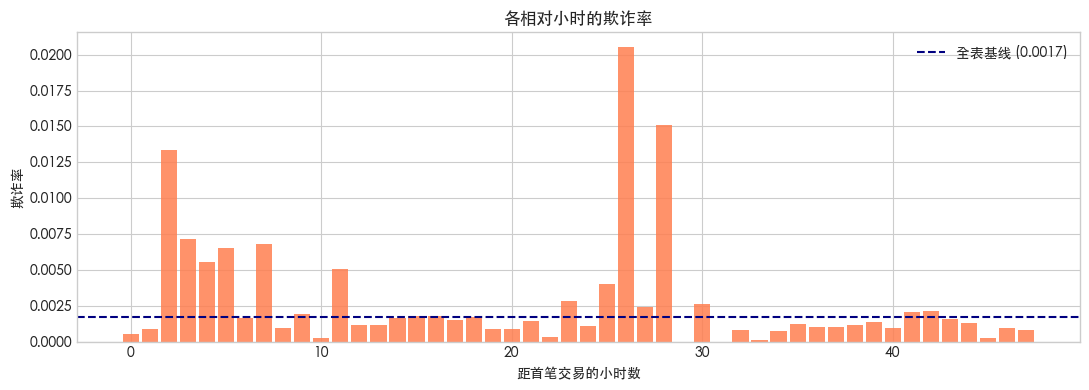

,总笔数,欺诈笔数,欺诈率,相对基线倍数
距起点小时,,,,
26,1752,36,0.0205,11.8947
28,1127,17,0.0151,8.7319
2,1576,21,0.0133,7.7134
3,1821,13,0.0071,4.1326
7,3368,23,0.0068,3.9531
5,1681,11,0.0065,3.7880
4,1082,6,0.0055,3.2100
11,8517,43,0.0050,2.9226



非活跃 vs 活跃（按每小时桶交易量划分）:
  非活跃: 欺诈率=0.0026, 样本数=85,884
  活跃: 欺诈率=0.0014, 样本数=198,923
  提升倍数（非活跃/活跃）: 1.89x


In [5]:
SECONDS_PER_HOUR = 3600

df_time = df.copy()
df_time['hours_since_start'] = (df_time['Time'] // SECONDS_PER_HOUR).astype(int)

# 按「相对小时」聚合：每桶总交易数、欺诈数、欺诈率、相对全表基线的 lift（当前小时欺诈率/全时段平均欺诈率）
hourly_rel = (
    df_time.groupby('hours_since_start')
    .agg(total=('Class', 'count'), fraud=('Class', 'sum'))
)
hourly_rel['fraud_rate'] = hourly_rel['fraud'] / hourly_rel['total']
hourly_rel['lift_vs_overall'] = hourly_rel['fraud_rate'] / FRAUD_RATE
hourly_rel = hourly_rel.rename(columns={
    'total': '总笔数',
    'fraud': '欺诈笔数',
    'fraud_rate': '欺诈率',
    'lift_vs_overall': '相对基线倍数',
})
hourly_rel.index.name = '距起点小时'

# 天数、桶总量
span_days = (df['Time'].max() - df['Time'].min()) / 86400
print(f'时间跨度: {df["Time"].min():.0f}秒 – {df["Time"].max():.0f}秒（约 {span_days:.1f} 天）')
print(f'相对小时桶数量: {hourly_rel.shape[0]}')

# 柱状图：哪些「相对小时」欺诈率偏高（如 hour 26、28 等）
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_rel.index, hourly_rel['欺诈率'], color='coral', alpha=0.85, width=0.85)
ax.axhline(FRAUD_RATE, color='navy', ls='--', label=f"{PLOT_LBL['baseline']} ({FRAUD_RATE:.4f})")  # 全表基线
ax.set_xlabel(PLOT_LBL['hours_x'])  # 距首笔交易的小时数
ax.set_ylabel(PLOT_LBL['fraud_rate'])  # 欺诈率
ax.set_title(PLOT_LBL['hour_fraud_title'])  # 各相对小时的欺诈率
ax.legend()
plt.tight_layout()
plt.show()

display(hourly_rel.sort_values('欺诈率', ascending=False).head(8).round(4))

# --- 数据驱动的「非活跃」：该小时桶交易量 < 全小时桶中位数 → 相对冷清 ---
txn_median = hourly_rel['总笔数'].median()
inactive_hours = hourly_rel.index[hourly_rel['总笔数'] < txn_median]
df_time['is_inactive'] = df_time['hours_since_start'].isin(inactive_hours)

print('\n非活跃 vs 活跃（按每小时桶交易量划分）:')
for label, mask in [('非活跃', df_time['is_inactive']), ('活跃', ~df_time['is_inactive'])]:
    sub = df_time[mask]
    print(f"  {label}: 欺诈率={sub['Class'].mean():.4f}, 样本数={len(sub):,}")
inactive_rate = df_time.loc[df_time['is_inactive'], 'Class'].mean()
active_rate = df_time.loc[~df_time['is_inactive'], 'Class'].mean()
print(f"  提升倍数（非活跃/活跃）: {inactive_rate / active_rate:.2f}x")


特征工程设想：  
1、`hours_since_start`：距首笔交易过了多少小时（时间事实）  
2、`is_inactive`：该相对小时桶交易量是否低于全小时桶中位数（流量事实）   

树模型自行组合 V1–V28 与上述事实特征；推断交给模型，不由特征工程替树完成。避免危险度活跃度等指标计算的本身不能完全体现实际情况而引入噪声


### 1.4 假设：短交易间隔暗示批量操作（velocity）

**局限：** 数据集无 card_id，按 Time 排序的全局间隔混合多张卡，结论仅作弱参考。


In [6]:
# --- 1.4 交易间隔（velocity 弱代理）---
# 思路：欺诈批量盗刷时相邻交易间隔可能更短。但本集无 card_id，只能按全局 Time 排序算 diff，
# 不同卡的流水会混在一起，结论仅作弱参考
df_sorted = df.sort_values('Time').reset_index(drop=True)
df_sorted['time_diff'] = df_sorted['Time'].diff()  # 与上一条记录的秒数差
td = df_sorted[df_sorted['time_diff'] > 0]  # 去掉首行 NaN 与重复时间戳

for label, g in [('正常', td[td['Class'] == 0]), ('欺诈', td[td['Class'] == 1])]:
    d = g['time_diff']
    print(f"{label}: 中位数={d.median():.1f}秒, 均值={d.mean():.1f}秒, 75%分位={d.quantile(0.75):.1f}秒")

# 若与上笔间隔 ≤ window 秒，该子集的欺诈率是否升高
for window in [1, 2, 3, 5, 7.5, 10, 60, 300, 3600]:
    mask = td['time_diff'] <= window
    rate = td.loc[mask, 'Class'].mean()
    print(f'距上一笔 ≤ {window} 秒: 样本数={mask.sum():,}, 欺诈率={rate:.4f}')


正常: 中位数=1.0秒, 均值=1.4秒, 75%分位=1.0秒
欺诈: 中位数=1.0秒, 均值=2.2秒, 75%分位=2.0秒
距上一笔 ≤ 1 秒: 样本数=100,059, 欺诈率=0.0014
距上一笔 ≤ 2 秒: 样本数=115,679, 欺诈率=0.0016
距上一笔 ≤ 3 秒: 样本数=119,835, 欺诈率=0.0016
距上一笔 ≤ 5 秒: 样本数=122,603, 欺诈率=0.0018
距上一笔 ≤ 7.5 秒: 样本数=123,602, 欺诈率=0.0019
距上一笔 ≤ 10 秒: 样本数=124,238, 欺诈率=0.0019
距上一笔 ≤ 60 秒: 样本数=124,591, 欺诈率=0.0019
距上一笔 ≤ 300 秒: 样本数=124,591, 欺诈率=0.0019
距上一笔 ≤ 3600 秒: 样本数=124,591, 欺诈率=0.0019


结果没什么意义，距离上一笔交易时间间隔短反而欺诈少，这不支持批量小额卡测试的逻辑，反而可能和欺诈常发于夜晚时段而非白天时段有关。  
**欺诈样本非常少，计算欺诈样本和上一个欺诈样本之间的时间diff恐怕没有什么意义。**

### 1.5 假设：大额交易（z-score）更可能是欺诈


In [7]:
# --- 1.5 大额 z-score ---
# 思路：行业上有「异常大额」风险；用全表 Amount 的 z-score 看高额尾部欺诈率是否高于基线。
# 注意：用全表均值/标准差算 z 仅适合 EDA；建模时应在训练折内 fit  scaler 避免泄露。
amt_mean, amt_std = df['Amount'].mean(), df['Amount'].std()
df_amt = df.copy()
df_amt['amount_z'] = (df_amt['Amount'] - amt_mean) / amt_std

for z in [1, 2, 3]:
    sub = df_amt[df_amt['amount_z'] > z]
    print(f'amount_z > {z}: 样本数={len(sub):,}, 欺诈率={sub["Class"].mean():.4f}（基线 {FRAUD_RATE:.4f}）')


amount_z > 1: 样本数=15,710, 欺诈率=0.0033（基线 0.0017）
amount_z > 2: 样本数=7,319, 欺诈率=0.0040（基线 0.0017）
amount_z > 3: 样本数=4,076, 欺诈率=0.0027（基线 0.0017）


可能不是很有用

### 1.7 假设验证小结

| 假设 | 结论 | 特征方向 |
|------|------|----------|
| Amount 分布不同 | 成立（KS 显著；欺诈中位数更低） | `log1p(Amount)` |
| 小额卡测试 | 成立 | `is_micro_testing`, `is_small_testing` |
| 1 欧尖峰 | 成立（约 23% 欺诈为 Amount=1.0） | `is_one_euro` |
| 非活跃/时间聚集 | 部分成立（低流量小时约 1.9x） | `hours_since_start`, `is_inactive` |
| 短间隔 velocity | 不成立 / 无法验证（无 card_id） | — |
| 大额 z-score | 弱成立 | 暂不造桶，用 `log1p(Amount)` |

V1–V28 直接进树模型，不做二次 PCA / V 极端簇 EDA，PCA和树的数据的切分和区别能力毕竟没有什么联系


---
## 2. Todo #2 — 基线模型与难样本分析

1. **2.0** 按 1.7 构造衍生特征，并提供 `feature_ablation()` 随时验证有效性。
2. **2.1** LightGBM / XGBoost 双模型 **logloss** 基线；1.7 特征通过 ablation / combo 对比增量。
3. **2.2** **Focal Loss** 实验：mirror 2.1 的 hold-out 基线、2.1d 组合对比、2.1e CV。
4. **2.3** 难样本分析：取验证集 **AUC-PR** 最高的 logloss 基线模型（见 2.1）。
5. **2.4** 本节结论。


In [8]:
# --- 2.0 1.7 特征构造 + 可复用验证工具 ---
# 按 1.7 / 1.2b 准备衍生特征；用 feature_ablation() 随时验证任意特征组合的有效性。

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)
import lightgbm as lgb
import xgboost as xgb

V_COLS = [c for c in df.columns if c.startswith('V')]
BASE_FEATURES = V_COLS + ['Amount', 'Time']

MODEL_FEATURES = BASE_FEATURES + ['hours_since_start', 'is_one_euro']  # Todo #4 默认特征集

# 1.7 假设验证小结 → 待验证的衍生特征（基线训练时不默认加入）
EDA_FEATURES = [
    'log1p_amount',        # Amount 分布不同
    'hours_since_start',   # 非活跃/时间聚集
    'is_micro_testing',    # Amount < 1 EUR
    'is_small_testing',    # 1 <= Amount <= 20 EUR（1.2b 合并小额带）
    'is_one_euro',         # Amount == 1.0 尖峰
    'is_inactive',         # 低流量相对小时桶
]
EDA_FEATURE_DOC = {
    'log1p_amount': 'np.log1p(Amount)',
    'hours_since_start': 'Time // 3600',
    'is_micro_testing': 'Amount < 1',
    'is_small_testing': '1 <= Amount <= 20',
    'is_one_euro': 'Amount == 1.0',
    'is_inactive': '相对小时桶交易量 < 全表小时中位数',
}


# 构造 1.7 中的衍生特征
def build_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_small_testing'] = (out['Amount'] >= 1) & (out['Amount'] <= 20)
    out['is_one_euro'] = out['Amount'] == 1.0
    hourly_cnt = out.groupby('hours_since_start').size()
    inactive_hours = hourly_cnt[hourly_cnt < hourly_cnt.median()].index
    out['is_inactive'] = out['hours_since_start'].isin(inactive_hours)
    return out


from sklearn.model_selection import StratifiedKFold

EARLY_STOPPING_ROUNDS = 50   # 早停常量
MAX_BOOST_ROUNDS = 1500
ES_FRAC = 0.20  # 早停监控集占 train 比例（80% fit / 20% ES）


BOOST_MODELS = ['LightGBM', 'XGBoost']

DEFAULT_CLASSIFICATION_THRESHOLD = 0.5


def pick_threshold_metrics(res: dict) -> dict:
    """从 eval_classifier 结果中提取与 threshold 对应的指标列（列名随阈值变化）。"""
    t = res['threshold']
    return {
        f'F1@{t}': res[f'F1@{t}'],
        f'Precision@{t}': res[f'Precision@{t}'],
        f'Recall@{t}': res[f'Recall@{t}'],
    }


def eval_summary_row(res: dict, extra: dict | None = None) -> dict:
    """汇总 eval_classifier 返回值为表格行"""
    row = {
        '模型': res['模型'],
        '特征数': res['特征数'],
        'AUC-PR': res['AUC-PR'],
        **pick_threshold_metrics(res),
    }
    if extra:
        row.update(extra)
    return row


def _split_early_stop_set(X_tr, y_tr, es_frac=ES_FRAC, random_state=42):
    """切分出用来验证早停的数据"""
    return train_test_split(
        X_tr, y_tr,
        test_size=es_frac,
        random_state=random_state,
        stratify=y_tr,
    )


def fit_classifier(clf, model_name: str, X_tr, y_tr, X_es=None, y_es=None):
    """训练（logloss 早停；Focal 版见 2.2）"""
    if X_es is None or y_es is None:
        clf.fit(X_tr, y_tr)
        return clf

    if model_name == 'LightGBM':
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_es, y_es)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
    elif model_name == 'XGBoost':
        clf.set_params(eval_metric='logloss')
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    else:
        clf.fit(X_tr, y_tr)
    return clf


def make_classifier(model_name: str, y_train: pd.Series, params: dict | None = None):
    """构造树（logloss + 类别不平衡权重；Focal 版见 2.2）"""
    params = dict(params or {})
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1,
            class_weight='balanced', random_state=42, verbose=-1,
        )
        defaults.update(params)
        return lgb.LGBMClassifier(**defaults)

    if model_name == 'XGBoost':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
            min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=spw,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=42, eval_metric='logloss', verbosity=0,
        )
        defaults.update(params)
        defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
        return xgb.XGBClassifier(**defaults)

    raise ValueError(f'未知模型: {model_name}')


def cross_val_auc_pr(
    model_name: str, X: pd.DataFrame, y: pd.Series,
    n_splits: int = 5, random_state: int = 42, params: dict | None = None,
):
    """交叉验证"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = _split_early_stop_set(X_tr, y_tr, random_state=random_state)
        clf = make_classifier(model_name, y_fit, params=params)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        scores.append(average_precision_score(y_va, clf.predict_proba(X_va)[:, 1]))
    return float(np.mean(scores)), float(np.std(scores))


def multi_seed_cv_report(
    model_name: str, data: pd.DataFrame, y: pd.Series, feature_cols: list,
    seeds=None, n_splits: int = 5, params: dict | None = None,
) -> pd.DataFrame:
    """多次不同随机种子交叉验证"""
    seeds = seeds or [42, 43, 44, 45, 46]
    X_sub = data[feature_cols]
    rows = []
    for seed in seeds:
        m, s = cross_val_auc_pr(model_name, X_sub, y, n_splits, seed, params)
        rows.append({'seed': seed, 'AUC-PR_mean': m, 'AUC-PR_std': s})
    out = pd.DataFrame(rows)
    out.loc['汇总'] = {'seed': 'mean±std', 'AUC-PR_mean': out['AUC-PR_mean'].mean(),
                       'AUC-PR_std': out['AUC-PR_mean'].std()}
    return out


def get_oof_proba(
    model_name: str, X: pd.DataFrame, y: pd.Series,
    n_splits: int = 5, random_state: int = 42, params: dict | None = None,
) -> np.ndarray:
    """得到全部样本预测概率"""
    oof = np.zeros(len(y), dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for tr_idx, va_idx in skf.split(X, y):
        X_tr_fold, y_tr_fold = X.iloc[tr_idx], y.iloc[tr_idx]
        X_fit, X_es, y_fit, y_es = _split_early_stop_set(X_tr_fold, y_tr_fold, random_state=random_state)
        clf = make_classifier(model_name, y_fit, params=params)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        oof[va_idx] = clf.predict_proba(X.iloc[va_idx])[:, 1]
    return oof


def eval_classifier(
    model_name: str,
    X_train, y_train, X_val, y_val,
    threshold: float = DEFAULT_CLASSIFICATION_THRESHOLD,
    random_state: int = 42,
    loss: str = 'logloss',
) -> dict:
    """不交叉验证，直接训练评估模型"""
    X_fit, X_es, y_fit, y_es = _split_early_stop_set(X_train, y_train, random_state=random_state)
    if loss != 'logloss':
        raise ValueError("loss='focal' 需先运行 2.2 基础设施 cell（会覆盖 make/fit/eval_classifier）")
    clf = make_classifier(model_name, y_fit)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    proba = clf.predict_proba(X_val)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        '模型': model_name,
        '特征数': X_train.shape[1],
        'AUC-PR': average_precision_score(y_val, proba),
        f"F1@{threshold}": f1_score(y_val, pred),
        f"Precision@{threshold}": precision_score(y_val, pred, zero_division=0),
        f"Recall@{threshold}": recall_score(y_val, pred, zero_division=0),
        'clf': clf,
        'proba': proba,
        'pred': pred,
        'threshold': threshold,
        'loss': loss,
    }


def feature_ablation(
    data: pd.DataFrame,
    candidate_features=None,
    base_features=None,
    model_name: str = 'LightGBM',
    test_size: float = 0.2,
    random_state: int = 42,
    include_all_combo: bool = True,
    threshold: float = DEFAULT_CLASSIFICATION_THRESHOLD,
) -> pd.DataFrame:
    """特征消融"""
    if base_features is None:
        base_features = BASE_FEATURES
    if candidate_features is None:
        candidate_features = list(EDA_FEATURES)  # list(...) 把可迭代对象复制成 list

    y = data['Class']             
    X_base = data[base_features]  
    X_train, X_val, y_train, y_val = train_test_split(
        X_base, y, test_size=test_size, random_state=random_state, stratify=y,
    )
    val_idx = y_val.index        

    specs = [('基线', base_features)]  # 列表里放元组 (字符串, 列表)
    for f in candidate_features:
        specs.append((f'+{f}', base_features + [f]))  # 列表 + [元素] 生成新列表，不修改原列表
    if include_all_combo and candidate_features:
        specs.append(('+全部候选', base_features + list(candidate_features)))

    rows = []
    base_ap = None
    for label, cols in specs:      # 特征集名称 + 特征列
        missing = [c for c in cols if c not in data.columns]
        if missing:
            raise KeyError(f'缺少列: {missing}')
        X = data.loc[X_train.index, cols] 
        X_va = data.loc[val_idx, cols]
        res = eval_classifier(model_name, X, y_train, X_va, y_val, threshold=threshold)
        if base_ap is None:
            base_ap = res['AUC-PR']
        rows.append({
            '特征集': label,
            '特征数': res['特征数'],
            'AUC-PR': res['AUC-PR'],
            **pick_threshold_metrics(res),
            'Δ AUC-PR': res['AUC-PR'] - base_ap,
        })
    # 建表 → 按列降序 → 重置行号；drop=True 不保留旧 index 列
    return pd.DataFrame(rows).sort_values('AUC-PR', ascending=False).reset_index(drop=True)


df_model = build_eda_features(df)

print('1.7 衍生特征已就绪（训练基线时默认不加入，仅 ablation 时选用）：')
display(pd.DataFrame({
    '特征': EDA_FEATURES,
    '定义': [EDA_FEATURE_DOC[f] for f in EDA_FEATURES],
}))


1.7 衍生特征已就绪（训练基线时默认不加入，仅 ablation 时选用）：


,特征,定义
0,log1p_amount,np.log1p(Amount)
1,hours_since_start,Time // 3600
2,is_micro_testing,Amount < 1
3,is_small_testing,1 <= Amount <= 20
4,is_one_euro,Amount == 1.0
5,is_inactive,相对小时桶交易量 < 全表小时中位数


In [9]:
# --- 2.1 双模型基线（仅 V + Amount + Time）+ 1.7 特征 ablation ---

X = df_model[BASE_FEATURES]
y = df_model['Class']
# 划分：80% 训练 / 20% 验证；早停监控集从 X_train 内再切 15%（eval_classifier → _split_early_stop_set）
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

baseline_rows = []
baseline_models = {}
baseline_proba = {}

EVAL_THRESHOLD = DEFAULT_CLASSIFICATION_THRESHOLD

for model_name in ['LightGBM', 'XGBoost']:
    res = eval_classifier(
        model_name, X_train, y_train, X_val, y_val, threshold=EVAL_THRESHOLD,
    )
    baseline_models[model_name] = res['clf']
    baseline_proba[model_name] = res['proba']
    baseline_rows.append(eval_summary_row(res))

baseline_metrics = pd.DataFrame(baseline_rows)
print('=== 双模型基线（无 1.7 衍生特征）===')
display(baseline_metrics.round(4))

BEST_MODEL_NAME = baseline_metrics.loc[baseline_metrics['AUC-PR'].idxmax(), '模型']
val_proba = baseline_proba[BEST_MODEL_NAME]
val_pred = (val_proba >= EVAL_THRESHOLD).astype(int)
clf = baseline_models[BEST_MODEL_NAME]

print(f'\n难样本分析模型: {BEST_MODEL_NAME}（验证集 AUC-PR 最高）')
print(f'混淆矩阵 [ [TN FP], [FN TP] ] (@{EVAL_THRESHOLD}):')
print(confusion_matrix(y_val, val_pred))

ABLATION_MODEL = 'XGBoost'
eda_ablation = feature_ablation(
    df_model,
    candidate_features=EDA_FEATURES,
    model_name=ABLATION_MODEL,
)
print(f'\n=== 1.7 特征 ablation（{ABLATION_MODEL}，固定划分）===')
display(eda_ablation.round(4))
# print('用法: feature_ablation(df_model, candidate_features=["is_one_euro"], model_name="XGBoost")')


=== 双模型基线（无 1.7 衍生特征）===


,模型,特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5
0,LightGBM,30,0.8767,0.8469,0.8469,0.8469
1,XGBoost,30,0.8756,0.8586,0.8817,0.8367



难样本分析模型: LightGBM（验证集 AUC-PR 最高）
混淆矩阵 [ [TN FP], [FN TP] ] (@0.5):
[[56849    15]
 [   15    83]]

=== 1.7 特征 ablation（XGBoost，固定划分）===


,特征集,特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR
0,+log1p_amount,31,0.8781,0.8571,0.8901,0.8265,0.0026
1,+is_micro_testing,31,0.8776,0.8571,0.8901,0.8265,0.0020
2,+is_inactive,31,0.8773,0.8526,0.8804,0.8265,0.0017
3,+hours_since_start,31,0.8772,0.8526,0.8804,0.8265,0.0016
4,+is_one_euro,31,0.8768,0.8571,0.8901,0.8265,0.0013
5,+is_small_testing,31,0.8768,0.8586,0.8817,0.8367,0.0012
6,基线,30,0.8756,0.8586,0.8817,0.8367,0.0000
7,+全部候选,36,0.8707,0.8438,0.8617,0.8265,-0.0049


In [10]:
ABLATION_MODEL = 'LightGBM'
eda_ablation = feature_ablation(
    df_model,
    candidate_features=EDA_FEATURES,
    model_name=ABLATION_MODEL,
)
print(f'\n=== 1.7 特征 ablation（{ABLATION_MODEL}，固定划分）===')
display(eda_ablation.round(4))
# print('用法: feature_ablation(df_model, candidate_features=["is_one_euro"], model_name="XGBoost")')


=== 1.7 特征 ablation（LightGBM，固定划分）===


,特征集,特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR
0,基线,30,0.8767,0.8469,0.8469,0.8469,0.0000
1,+log1p_amount,31,0.8764,0.8601,0.8737,0.8469,-0.0003
2,+hours_since_start,31,0.8754,0.8557,0.8646,0.8469,-0.0013
3,+全部候选,36,0.8748,0.8454,0.8542,0.8367,-0.0019
4,+is_one_euro,31,0.8742,0.8601,0.8737,0.8469,-0.0024
5,+is_micro_testing,31,0.8733,0.8557,0.8646,0.8469,-0.0033
6,+is_small_testing,31,0.8715,0.8557,0.8646,0.8469,-0.0052
7,+is_inactive,31,0.8714,0.8646,0.8830,0.8469,-0.0053


使用早停法容易造成了训练或验证集的欺诈样本数据量不足（在训练集中继续切分用来判断是否早停），若用average_precision 等对正样本数量敏感的指标作为早停依据会导致LightGBM的AUC-PR对比不使用早停法异常下降非常多  
 
应当考虑拿掉is_inactive、is_small_testing、log1p_amount和hours_since_start特征  
is_micro_testing对LightGBM和XGBoost效果差别那么大，为什么？可能只有is_one_euro是明确有用的  
然后就是全部候选特征为什么表现好？？？应当尝试特征的排列组合。这对特征交叉的效果也有提醒，应当总体考量  
  
CV的结果可能更稳定

In [11]:
# --- 2.1d 剔除负面特征后的组合效果（与 2.1 同划分、同模型）---
EDA_MINUS_INACTIVE = [f for f in EDA_FEATURES if f != 'is_inactive']
EDA_MINUS_INACTIVE_SMALL = [f for f in EDA_FEATURES if f not in ('is_inactive', 'is_small_testing')]
EDA_MINUS_INACTIVE_SMALL_NO_HOURS = [f for f in EDA_MINUS_INACTIVE_SMALL if f != 'hours_since_start']
EDA_MINUS_INACTIVE_SMALL_NO_HOURS_LOG = [f for f in EDA_MINUS_INACTIVE_SMALL_NO_HOURS if f != 'log1p_amount']
EDA_CURATED = ['hours_since_start', 'is_one_euro']  # 2.1 ablation 正增量特征


COMBO_SPECS = [
    ([], '基线（无 1.7 衍生）'),
    (EDA_FEATURES, '基线 + 全部 1.7'),
    (EDA_MINUS_INACTIVE, '去掉 is_inactive'),
    (EDA_MINUS_INACTIVE_SMALL, '去掉 is_inactive + is_small_testing'),
    (EDA_MINUS_INACTIVE_SMALL_NO_HOURS, '再去掉 hours_since_start'),
    (EDA_MINUS_INACTIVE_SMALL_NO_HOURS_LOG, '再去掉 log1p_amount'),
    (EDA_CURATED, '仅保留 hours_since_start + is_one_euro'),
]


def eval_feature_combo(
    extra_features,
    label: str,
    model_name: str = None,
    threshold: float = DEFAULT_CLASSIFICATION_THRESHOLD,
    loss: str = 'logloss',
    baseline_df=None,
) -> dict:
    """基线特征 + extra_features，固定 random_state=42 划分。"""
    model_name = model_name or ABLATION_MODEL
    base_df = baseline_df if baseline_df is not None else baseline_metrics
    cols = BASE_FEATURES + list(extra_features)
    X = df_model[cols]
    y = df_model['Class']
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y,
    )
    res = eval_classifier(model_name, X_tr, y_tr, X_va, y_va, threshold=threshold, loss=loss)
    base_ap = base_df.loc[base_df['模型'] == model_name, 'AUC-PR'].iloc[0]
    return {
        '特征组合': label,
        '附加特征数': len(extra_features),
        '总特征数': len(cols),
        'AUC-PR': res['AUC-PR'],
        **pick_threshold_metrics(res),
        'Δ AUC-PR vs 无衍生基线': res['AUC-PR'] - base_ap,
    }


def run_combo_report(model_name: str, loss: str = 'logloss', baseline_df=None) -> pd.DataFrame:
    rows = [
        eval_feature_combo(extra, label, model_name=model_name, loss=loss, baseline_df=baseline_df)
        for extra, label in COMBO_SPECS
    ]
    return pd.DataFrame(rows).sort_values('AUC-PR', ascending=False).reset_index(drop=True)


combo_compare = run_combo_report(ABLATION_MODEL, loss='logloss', baseline_df=baseline_metrics)

print(f'模型: {ABLATION_MODEL} | 对比：剔除负面特征前后的组合效果')
display(combo_compare.round(4))


模型: LightGBM | 对比：剔除负面特征前后的组合效果


,特征组合,附加特征数,总特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR vs 无衍生基线
0,再去掉 hours_since_start,3,33,0.8826,0.8750,0.8936,0.8571,0.0059
1,再去掉 log1p_amount,2,32,0.8788,0.8513,0.8557,0.8469,0.0021
2,去掉 is_inactive,5,35,0.8782,0.8601,0.8737,0.8469,0.0015
3,去掉 is_inactive + is_small_testing,4,34,0.8776,0.8557,0.8646,0.8469,0.0009
4,仅保留 hours_since_start + is_one_euro,2,32,0.8774,0.8557,0.8646,0.8469,0.0008
5,基线（无 1.7 衍生）,0,30,0.8767,0.8469,0.8469,0.8469,0.0000
6,基线 + 全部 1.7,6,36,0.8748,0.8454,0.8542,0.8367,-0.0019


LightGBM只保留log1p_amount + is_micro_testing + is_one_euro

In [12]:
# --- 2.1d（XGBoost）剔除负面特征后的组合效果 ---
combo_compare_xgb = run_combo_report('XGBoost', loss='logloss', baseline_df=baseline_metrics)
print('模型: XGBoost | 对比：剔除负面特征前后的组合效果')
display(combo_compare_xgb.round(4))


模型: XGBoost | 对比：剔除负面特征前后的组合效果


,特征组合,附加特征数,总特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR vs 无衍生基线
0,去掉 is_inactive + is_small_testing,4,34,0.8772,0.8542,0.8723,0.8367,0.0016
1,去掉 is_inactive,5,35,0.8770,0.8705,0.8842,0.8571,0.0015
2,再去掉 log1p_amount,2,32,0.8768,0.8511,0.8889,0.8163,0.0012
3,基线（无 1.7 衍生）,0,30,0.8756,0.8586,0.8817,0.8367,0.0000
4,再去掉 hours_since_start,3,33,0.8737,0.8586,0.8817,0.8367,-0.0019
5,仅保留 hours_since_start + is_one_euro,2,32,0.8726,0.8526,0.8804,0.8265,-0.0029
6,基线 + 全部 1.7,6,36,0.8707,0.8438,0.8617,0.8265,-0.0049


XGBoost保留全部1.7中特征，除了is_inactive

In [13]:
# --- 2.1e CV 基线报告（MODEL_FEATURES）---
X_cv = df_model[MODEL_FEATURES]
y_cv = df_model['Class']

cv_rows = []
for model_name in ['LightGBM', 'XGBoost']:
    m, s = cross_val_auc_pr(model_name, X_cv, y_cv, n_splits=5, random_state=42)
    cv_rows.append({'模型': model_name, 'CV_AUC-PR_mean': m, 'CV_AUC-PR_std': s})
print('=== 5-fold CV（MODEL_FEATURES）===')
display(pd.DataFrame(cv_rows).round(4))

print('\n=== LightGBM 多 seed 稳定性 ===')
display(multi_seed_cv_report('LightGBM', df_model, y_cv, MODEL_FEATURES).round(4))


=== 5-fold CV（MODEL_FEATURES）===


,模型,CV_AUC-PR_mean,CV_AUC-PR_std
0,LightGBM,0.8594,0.0238
1,XGBoost,0.8605,0.0254



=== LightGBM 多 seed 稳定性 ===


,seed,AUC-PR_mean,AUC-PR_std
0,42,0.8594,0.0238
1,43,0.8611,0.0247
2,44,0.8574,0.0248
3,45,0.8567,0.0220
4,46,0.8568,0.0365
汇总,mean±std,0.8583,0.0019


In [14]:
# --- 2.1e CV 基线报告（BASE_FEATURES）---
X_cv = df_model[BASE_FEATURES]
y_cv = df_model['Class']

cv_rows = []
for model_name in ['LightGBM', 'XGBoost']:
    m, s = cross_val_auc_pr(model_name, X_cv, y_cv, n_splits=5, random_state=42)
    cv_rows.append({'模型': model_name, 'CV_AUC-PR_mean': m, 'CV_AUC-PR_std': s})
print('=== 5-fold CV（BASE_FEATURES）===')
display(pd.DataFrame(cv_rows).round(4))

print('\n=== LightGBM 多 seed 稳定性 ===')
display(multi_seed_cv_report('LightGBM', df_model, y_cv, BASE_FEATURES).round(4))

=== 5-fold CV（BASE_FEATURES）===


,模型,CV_AUC-PR_mean,CV_AUC-PR_std
0,LightGBM,0.8578,0.0217
1,XGBoost,0.8578,0.0273



=== LightGBM 多 seed 稳定性 ===


,seed,AUC-PR_mean,AUC-PR_std
0,42,0.8578,0.0217
1,43,0.8598,0.0270
2,44,0.8562,0.0249
3,45,0.8560,0.0217
4,46,0.8594,0.0339
汇总,mean±std,0.8578,0.0018


### 2.2 Focal Loss 基线（LGB + XGB）

**下方「2.2.0 基础设施」cell**（会覆盖 `eval_classifier` 等），再跑 2.2a/b/c。

训练目标 Focal Loss，早停监控 focal loss，`ES_FRAC=0.20`（与 2.1 logloss 一致）。


In [18]:
# --- 2.2.0 Focal Loss 基础设施 ---
# 运行后会覆盖 2.0 的 make/fit/eval/cross_val；2.1 logloss 已跑完不受影响。
# 必须先跑本 cell，再跑 2.2a/b/c。

FOCAL_GAMMA = 2.0


def _focal_alpha(y_train: pd.Series) -> float:
    """正类权重：默认 max(0.75, 正类比例)，避免 α=0.25 过度压低欺诈梯度。"""
    pos_rate = float((y_train == 1).mean())
    return max(0.75, pos_rate)


def _sigmoid(z):
    z = np.clip(np.asarray(z, dtype=float), -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-z))


def _focal_grad_hess(y_true, y_pred, alpha, gamma=FOCAL_GAMMA):
    """Focal grad/hess 对 raw score（logit）。公式与常用 LGB/XGB focal 实现一致。"""
    y = np.asarray(y_true, dtype=float)
    z = np.asarray(y_pred, dtype=float)
    p = _sigmoid(z)
    p = np.clip(p, 1e-7, 1 - 1e-7)

    grad = np.empty_like(p)
    hess = np.empty_like(p)
    pos = y == 1
    neg = ~pos

    grad[pos] = alpha * (1 - p[pos]) ** gamma * (gamma * p[pos] * np.log(p[pos]) + p[pos] - 1)
    hess[pos] = alpha * (1 - p[pos]) ** gamma * (
        gamma * p[pos] * (1 - p[pos]) * (1 + gamma * np.log(p[pos]))
        + p[pos] * (1 - p[pos])
    )
    grad[neg] = (1 - alpha) * p[neg] ** gamma * (
        -gamma * (1 - p[neg]) * np.log(1 - p[neg]) + p[neg]
    )
    hess[neg] = (1 - alpha) * p[neg] ** gamma * (
        -gamma * (1 - p[neg]) * (1 - 2 * p[neg] - gamma * np.log(1 - p[neg]))
        + p[neg] * (1 - p[neg])
    )
    # LGB/XGB 分裂要求 hess 非负；focal 解析 hess 在极端不平衡下会为负
    hess = np.abs(hess)
    hess = np.maximum(hess, 1e-4)
    return grad, hess


def _focal_lgb_objective(y_true, y_pred):
    alpha = _focal_alpha(y_true)
    return _focal_grad_hess(y_true, y_pred, alpha)


def _focal_xgb_objective(y_true, y_pred):
    alpha = _focal_alpha(y_true)
    return _focal_grad_hess(y_true, y_pred, alpha)


def _focal_loss_mean(y_true, y_pred, alpha, gamma=FOCAL_GAMMA):
    y = np.asarray(y_true, dtype=float)
    p = _sigmoid(y_pred)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    pt = np.where(y == 1, p, 1 - p)
    alpha_t = np.where(y == 1, alpha, 1 - alpha)
    return float(np.mean(-alpha_t * (1 - pt) ** gamma * np.log(pt)))


def _focal_eval_lgb(y_true, y_pred):
    """LGB sklearn：2 参数 = (labels, raw_scores)，返回 (name, value, higher_better)。"""
    alpha = _focal_alpha(y_true)
    return 'focal_loss', _focal_loss_mean(y_true, y_pred, alpha), False


def _focal_eval_xgb(y_true, y_pred):
    """XGB sklearn：2 参数 = (labels, raw_scores)，返回标量。"""
    alpha = _focal_alpha(y_true)
    return _focal_loss_mean(y_true, y_pred, alpha)


def _positive_class_proba(clf, X, model_name: str, loss: str = 'logloss'):
    """custom objective 下用 raw score + sigmoid 得到欺诈概率。"""
    if loss == 'focal':
        if model_name == 'LightGBM':
            raw = clf.predict(X, raw_score=True)
            return _sigmoid(raw)
        if model_name == 'XGBoost':
            raw = clf.predict(X, output_margin=True)
            return _sigmoid(raw)
    out = np.asarray(clf.predict_proba(X))
    if out.ndim == 1:
        return out
    return out[:, 1]


def make_classifier(
    model_name: str, y_train: pd.Series, params: dict | None = None, loss: str = 'logloss',
):
    params = dict(params or {})
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
        )
        if loss == 'focal':
            defaults['objective'] = _focal_lgb_objective
        else:
            defaults['class_weight'] = 'balanced'
        defaults.update(params)
        return lgb.LGBMClassifier(**defaults)

    if model_name == 'XGBoost':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
            min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=42, verbosity=0,
        )
        if loss == 'focal':
            defaults['objective'] = _focal_xgb_objective
            defaults['eval_metric'] = _focal_eval_xgb
        else:
            defaults['scale_pos_weight'] = spw
            defaults['eval_metric'] = 'logloss'
        defaults.update(params)
        defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
        return xgb.XGBClassifier(**defaults)

    raise ValueError(f'未知模型: {model_name}')


def fit_classifier(
    clf, model_name: str, X_tr, y_tr, X_es=None, y_es=None, loss: str = 'logloss',
):
    if X_es is None or y_es is None:
        clf.fit(X_tr, y_tr)
        return clf

    if model_name == 'LightGBM':
        eval_metric = _focal_eval_lgb if loss == 'focal' else 'binary_logloss'
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_es, y_es)],
            eval_metric=eval_metric,
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
    elif model_name == 'XGBoost':
        metric = _focal_eval_xgb if loss == 'focal' else 'logloss'
        clf.set_params(eval_metric=metric)
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    else:
        clf.fit(X_tr, y_tr)
    return clf


def eval_classifier(
    model_name: str,
    X_train, y_train, X_val, y_val,
    threshold: float = DEFAULT_CLASSIFICATION_THRESHOLD,
    random_state: int = 42,
    loss: str = 'logloss',
) -> dict:
    X_fit, X_es, y_fit, y_es = _split_early_stop_set(
        X_train, y_train, es_frac=ES_FRAC, random_state=random_state,
    )
    clf = make_classifier(model_name, y_fit, loss=loss)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es, loss=loss)
    proba = _positive_class_proba(clf, X_val, model_name=model_name, loss=loss)
    pred = (proba >= threshold).astype(int)
    return {
        '模型': model_name,
        '特征数': X_train.shape[1],
        'AUC-PR': average_precision_score(y_val, proba),
        f"F1@{threshold}": f1_score(y_val, pred),
        f"Precision@{threshold}": precision_score(y_val, pred, zero_division=0),
        f"Recall@{threshold}": recall_score(y_val, pred, zero_division=0),
        'clf': clf,
        'proba': proba,
        'pred': pred,
        'threshold': threshold,
        'loss': loss,
    }


def cross_val_auc_pr(
    model_name: str, X: pd.DataFrame, y: pd.Series,
    n_splits: int = 5, random_state: int = 42, params: dict | None = None,
    loss: str = 'logloss',
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = _split_early_stop_set(
            X_tr, y_tr, es_frac=ES_FRAC, random_state=random_state,
        )
        clf = make_classifier(model_name, y_fit, params=params, loss=loss)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es, loss=loss)
        scores.append(average_precision_score(
            y_va, _positive_class_proba(clf, X_va, model_name=model_name, loss=loss),
        ))
    return float(np.mean(scores)), float(np.std(scores))


def multi_seed_cv_report(
    model_name: str, data: pd.DataFrame, y: pd.Series, feature_cols: list,
    seeds=None, n_splits: int = 5, params: dict | None = None, loss: str = 'logloss',
) -> pd.DataFrame:
    seeds = seeds or [42, 43, 44, 45, 46]
    X_sub = data[feature_cols]
    rows = []
    for seed in seeds:
        m, s = cross_val_auc_pr(model_name, X_sub, y, n_splits, seed, params, loss=loss)
        rows.append({'seed': seed, 'AUC-PR_mean': m, 'AUC-PR_std': s})
    out = pd.DataFrame(rows)
    out.loc['汇总'] = {'seed': 'mean±std', 'AUC-PR_mean': out['AUC-PR_mean'].mean(),
                       'AUC-PR_std': out['AUC-PR_mean'].std()}
    return out


print(f"Focal 基础设施已加载（ES_FRAC={ES_FRAC}，α=max(0.75, pos_rate)）")


Focal 基础设施已加载（ES_FRAC=0.2，α=max(0.75, pos_rate)）


In [19]:
# --- 2.2a Focal Loss hold-out 基线（BASE_FEATURES）---
focal_baseline_rows = []
focal_baseline_models = {}
focal_baseline_proba = {}

for model_name in BOOST_MODELS:
    res = eval_classifier(
        model_name, X_train, y_train, X_val, y_val,
        threshold=EVAL_THRESHOLD, loss='focal',
    )
    focal_baseline_models[model_name] = res['clf']
    focal_baseline_proba[model_name] = res['proba']
    focal_baseline_rows.append(eval_summary_row(res))

focal_baseline_metrics = pd.DataFrame(focal_baseline_rows)
print('=== Focal Loss 双模型基线（无 1.7 衍生特征）===')
display(focal_baseline_metrics.round(4))


=== Focal Loss 双模型基线（无 1.7 衍生特征）===


,模型,特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5
0,LightGBM,30,0.8786,0.8619,0.9398,0.7959
1,XGBoost,30,0.8738,0.8663,0.9101,0.8265


In [20]:
# --- 2.2b Focal Loss 特征组合（LightGBM，mirror 2.1d）---
focal_combo_lgb = run_combo_report('LightGBM', loss='focal', baseline_df=focal_baseline_metrics)
print('模型: LightGBM | Focal Loss | 组合对比')
display(focal_combo_lgb.round(4))


模型: LightGBM | Focal Loss | 组合对比


,特征组合,附加特征数,总特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR vs 无衍生基线
0,再去掉 hours_since_start,3,33,0.8791,0.8757,0.9310,0.8265,0.0005
1,基线 + 全部 1.7,6,36,0.8786,0.8696,0.9302,0.8163,0.0000
2,基线（无 1.7 衍生）,0,30,0.8786,0.8619,0.9398,0.7959,0.0000
3,去掉 is_inactive,5,35,0.8783,0.8696,0.9302,0.8163,-0.0002
4,再去掉 log1p_amount,2,32,0.8773,0.8478,0.9070,0.7959,-0.0013
5,仅保留 hours_since_start + is_one_euro,2,32,0.8773,0.8478,0.9070,0.7959,-0.0013
6,去掉 is_inactive + is_small_testing,4,34,0.8771,0.8696,0.9302,0.8163,-0.0015


In [21]:
# --- 2.2b Focal Loss 特征组合（XGBoost，mirror 2.1d）---
focal_combo_xgb = run_combo_report('XGBoost', loss='focal', baseline_df=focal_baseline_metrics)
print('模型: XGBoost | Focal Loss | 组合对比')
display(focal_combo_xgb.round(4))


模型: XGBoost | Focal Loss | 组合对比


,特征组合,附加特征数,总特征数,AUC-PR,F1@0.5,Precision@0.5,Recall@0.5,Δ AUC-PR vs 无衍生基线
0,去掉 is_inactive + is_small_testing,4,34,0.8757,0.8757,0.9310,0.8265,0.0019
1,去掉 is_inactive,5,35,0.8754,0.8571,0.8901,0.8265,0.0016
2,基线（无 1.7 衍生）,0,30,0.8738,0.8663,0.9101,0.8265,0.0000
3,基线 + 全部 1.7,6,36,0.8731,0.8556,0.8989,0.8163,-0.0006
4,再去掉 hours_since_start,3,33,0.8719,0.8449,0.8876,0.8061,-0.0019
5,再去掉 log1p_amount,2,32,0.8700,0.8663,0.9101,0.8265,-0.0037
6,仅保留 hours_since_start + is_one_euro,2,32,0.8693,0.8602,0.9091,0.8163,-0.0044


In [22]:
# --- 2.2c Focal Loss CV 基线（MODEL_FEATURES）---
X_cv = df_model[MODEL_FEATURES]
y_cv = df_model['Class']

focal_cv_rows = []
for model_name in BOOST_MODELS:
    m, s = cross_val_auc_pr(model_name, X_cv, y_cv, n_splits=5, random_state=42, loss='focal')
    focal_cv_rows.append({'模型': model_name, 'CV_AUC-PR_mean': m, 'CV_AUC-PR_std': s})
print('=== Focal Loss 5-fold CV（MODEL_FEATURES）===')
display(pd.DataFrame(focal_cv_rows).round(4))


=== Focal Loss 5-fold CV（MODEL_FEATURES）===


,模型,CV_AUC-PR_mean,CV_AUC-PR_std
0,LightGBM,0.8583,0.0219
1,XGBoost,0.8563,0.0227


这样看的话似乎找不到使用Focal Loss代替scale_pos_weight的理由？效果差不多，还需要更大的早停法监控集

### 2.3 难样本标注


当前难样本分析模型: LightGBM
难样本分布（验证集）:


,样本数
hard_tag,
easy,56929
hard_FP,15
hard_FN,15
hard_uncertain,3


各组画像（含 Amount 区间；无欺诈组「欺诈Amount」= 全组 Amount 区间）:


,组别,样本数,欺诈笔数,Amount中位数,Amount最小,Amount最大,欺诈Amount最小,欺诈Amount最大,欺诈Amount备注,hours_since_start中位数,平均p_fraud
0,easy,56929,83,22.00,0.0,12910.93,0.0,1809.68,组内欺诈,23.0,0.0018
1,hard_FN,15,15,3.79,1.0,635.10,1.0,635.10,组内欺诈,20.0,0.0425
2,hard_FP,15,0,1.00,0.0,1059.28,0.0,1059.28,无欺诈(全组Amount),27.0,0.7875
3,hard_uncertain,3,0,1.00,1.0,60.00,1.0,60.00,无欺诈(全组Amount),20.0,0.4335


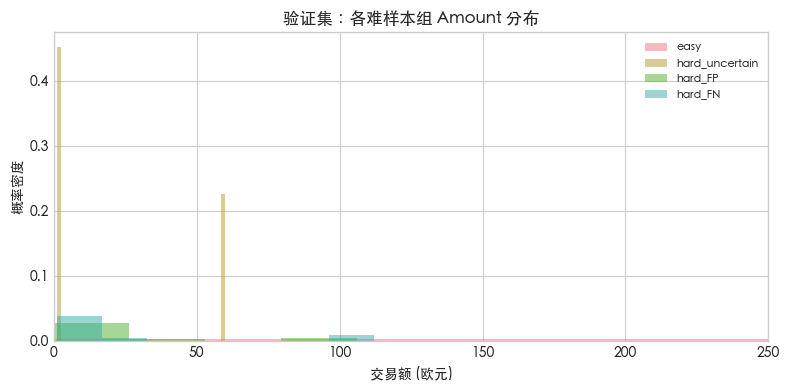

hard_FP: 15 行 -> output/hard_samples_2_3/hard_FP_samples.csv
hard_FN: 15 行 -> output/hard_samples_2_3/hard_FN_samples.csv
hard_uncertain: 3 行 -> output/hard_samples_2_3/hard_uncertain_samples.csv
合并: 33 行 -> output/hard_samples_2_3/hard_FP_FN_uncertain_all.csv


In [31]:
# --- 2.3 难样本标注 + Amount/Time 画像（基于 AUC-PR 最优 logloss 基线）---
# 依赖 2.1 已产出：BEST_MODEL_NAME, val_proba, val_pred, X_val, y_val, EVAL_THRESHOLD

print(f'当前难样本分析模型: {BEST_MODEL_NAME}')

# 在验证集特征表上拼接标签与预测，便于逐行打标
val_df = X_val.copy()                         
val_df['Class'] = y_val.values             
val_df['p_fraud'] = val_proba  # 2.1 最优模型对验证集的欺诈概率预测
val_df['pred'] = val_pred  # 阈值 @EVAL_THRESHOLD 下的 0/1 预测
val_df['hours_since_start'] = (val_df['Time'] // 3600).astype(int)  # 仅画像用，非训练特征

# 阈值附近不确定带宽度（|p - threshold| < band → hard_uncertain）
UNCERTAIN_BAND = 0.15


def tag_hard(row, threshold: float | None = None):
    """判定难样本类型"""
    if threshold is None:
        # globals().get：若未传 threshold，回退到 notebook 全局 EVAL_THRESHOLD
        threshold = globals().get('EVAL_THRESHOLD', DEFAULT_CLASSIFICATION_THRESHOLD)
    if row['Class'] == 1 and row['p_fraud'] < threshold:
        return 'hard_FN'  # 漏报：真欺诈但概率低于阈值
    if row['Class'] == 0 and row['p_fraud'] >= threshold:
        return 'hard_FP'  # 误报：正常但概率高于阈值
    if (threshold - UNCERTAIN_BAND) < row['p_fraud'] < (threshold + UNCERTAIN_BAND):
        return 'hard_uncertain'  # 阈值附近，对调阈值敏感
    return 'easy'


val_df['hard_tag'] = val_df.apply(tag_hard, axis=1)  # apply：每行（axis=1）调用 tag_hard，返回新列

print('难样本分布（验证集）:')
display(val_df['hard_tag'].value_counts().to_frame('样本数'))

# 各组画像：全组 Amount 统计 + 组内欺诈子集 Amount 区间
# hard_FP 等组内无欺诈（欺诈笔数=0）时，「欺诈Amount」无定义 → 回退为全组 Amount 最小/最大，并在备注标明
profile_rows = []
for tag, g in val_df.groupby('hard_tag'):      # groupby：按 hard_tag 分组，(tag, 子DataFrame)
    fraud_amt = g.loc[g['Class'] == 1, 'Amount']  # 只取该组内的欺诈交易
    fraud_n = int(g['Class'].sum())
    amt_min, amt_max = g['Amount'].min(), g['Amount'].max()
    if fraud_n:
        fa_min, fa_max = float(fraud_amt.min()), float(fraud_amt.max())
        fa_note = '组内欺诈'
    else:
        # 误报 hard_FP 等：组内全是正常样本，欺诈金额区间不存在，用全组 Amount 代替
        fa_min, fa_max = float(amt_min), float(amt_max)
        fa_note = '无欺诈(全组Amount)'
    profile_rows.append({
        '组别': tag,
        '样本数': len(g),
        '欺诈笔数': fraud_n,
        'Amount中位数': g['Amount'].median(),
        'Amount最小': amt_min,
        'Amount最大': amt_max,
        '欺诈Amount最小': fa_min,
        '欺诈Amount最大': fa_max,
        '欺诈Amount备注': fa_note,
        'hours_since_start中位数': g['hours_since_start'].median(),
        '平均p_fraud': g['p_fraud'].mean(),
    })
print('各组画像（含 Amount 区间；无欺诈组「欺诈Amount」= 全组 Amount 区间）:')
display(pd.DataFrame(profile_rows).round(4))

# 分组 Amount 密度直方图（对比 hard_FN / hard_FP 是否集中在特定金额带）
fig, ax = plt.subplots(figsize=(8, 4))
for tag, color in [('easy', 'steelblue'), ('hard_uncertain', 'gray'),
                   ('hard_FP', 'orange'), ('hard_FN', 'crimson')]:
    g = val_df[val_df['hard_tag'] == tag]     
    if len(g):
        ax.hist(g['Amount'], bins=40, alpha=0.5, density=True, label=tag)
ax.set_xlim(0, 250)
ax.set_xlabel(PLOT_LBL['amount_x'])
ax.set_ylabel(PLOT_LBL['density'])
ax.set_title('验证集：各难样本组 Amount 分布')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- 2.3b 导出 FP / FN / uncertain 全量样本 ---
from pathlib import Path
HARD_EXPORT_DIR = Path('output/hard_samples_2_3')
HARD_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_val = val_df.copy()
export_val.insert(0, 'row_id', export_val.index)
export_cols = (
    ['row_id', 'Class', 'Amount', 'Time', 'hours_since_start', 'p_fraud', 'pred', 'hard_tag']
    + V_COLS
)

hard_export_specs = [
    ('hard_FP', 'hard_FP_samples.csv'),
    ('hard_FN', 'hard_FN_samples.csv'),
    ('hard_uncertain', 'hard_uncertain_samples.csv'),
]
for tag, fname in hard_export_specs:
    sub = export_val.loc[export_val['hard_tag'] == tag, export_cols].sort_values('row_id')
    sub.to_csv(HARD_EXPORT_DIR / fname, index=False)
    print(f'{tag}: {len(sub)} 行 -> {HARD_EXPORT_DIR / fname}')

all_hard = export_val.loc[
    export_val['hard_tag'].isin([t for t, _ in hard_export_specs]), export_cols
].sort_values(['hard_tag', 'row_id'])
all_hard.to_csv(HARD_EXPORT_DIR / 'hard_FP_FN_uncertain_all.csv', index=False)
print(f'合并: {len(all_hard)} 行 -> {HARD_EXPORT_DIR / "hard_FP_FN_uncertain_all.csv"}')


误报主要来自于0-25欧，其中1欧左右的误报很严重，75-115欧之间也有误报。  
漏报主要在1-30欧，也是小额的漏报多，100欧附近也有个漏报区间。  
这个是可以预见的。前面在研究is_small_testing时就发现（1,115]欧区间欺诈发生率较低，这可能导致了样本少。然后1欧这个小额测试的信号太强，以至于出现了一些1欧左右的正常交易被误报。

## 3. Todo #3 — 欺诈样本特征画像

**依赖：** 2.1 基线模型 + 2.3 难样本标注（`val_df`、`hard_tag`）。

**目的：**
1. **3.1** 在全表 492 笔欺诈的 V 空间做 KMeans，看欺诈是否存在可分的「子类型」，以此作为业务逻辑指导特征工程。
2. **3.2** 把验证集 `hard_FN` / `hard_FP` 投影到与全表一致的 PCA，对比 Amount 分布，判断漏报/误报是否集中在特定区域。

**注意：** 3.1 聚类只用欺诈样本，不泄露标签到验证流程；3.2 的 PCA 在 **全表 V** 上 fit，再 transform 验证集。


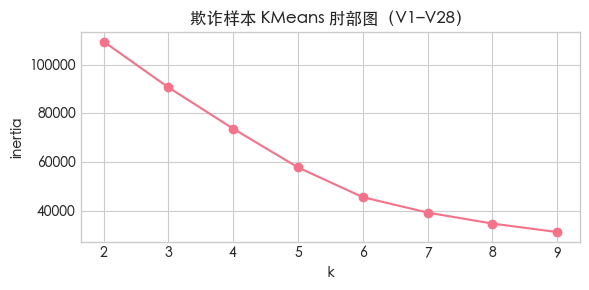

欺诈簇画像（全表 492 笔）:


,样本数,Amount中位数,Amount均值,hours_since_start中位数
fraud_cluster,,,,
0,160,7.96,103.47,23.0
1,14,1.00,2.31,26.5
2,219,8.00,158.44,21.0
3,93,59.68,95.01,11.0
4,6,1.00,1.00,18.0


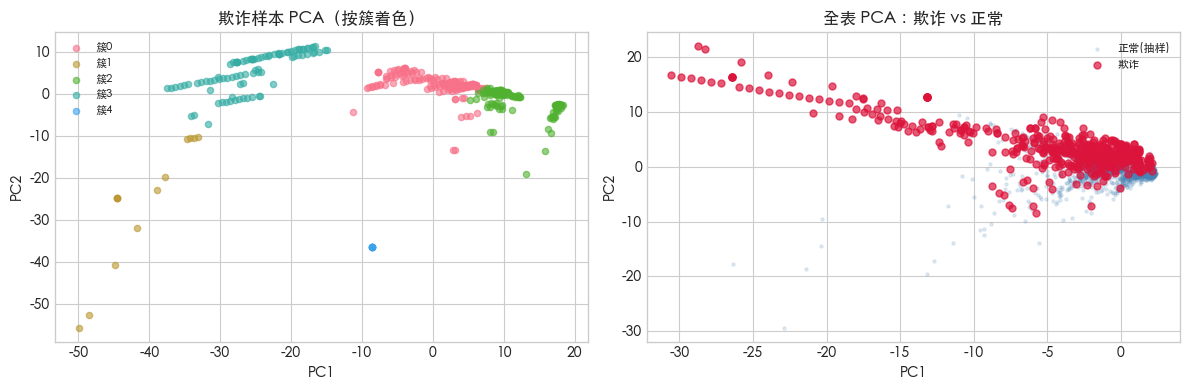

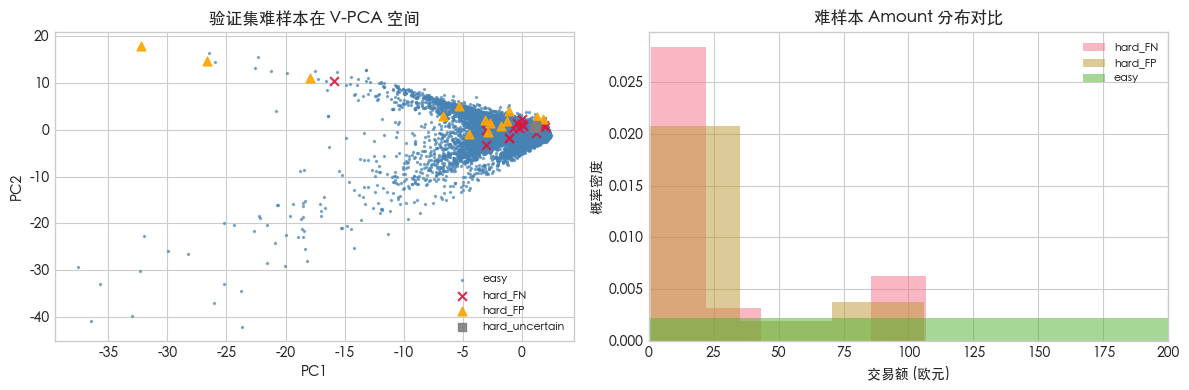

hard_FN Amount 中位数: 3.79 | hard_FP Amount 中位数: 1.00
结论：hard_FP 多集中在 1 EUR 小额带；hard_FN 金额更接近正常中位数，混在正常 PCA 带内 → 分簇子模型收益有限。


In [24]:
# --- 3.1 欺诈样本 V 空间聚类 + PCA ---
# 思路：V1–V28 已是 PCA 分量，但在「欺诈子集」内仍可能有多个模式（不同金额带/时段）。
# 先用kmeans看看有几种欺诈模式，具体就是肘部图选 k 值，再对欺诈样本聚类并做 2D PCA 可视化。
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

fraud_df = df_model[df_model['Class'] == 1].copy()  
X_fraud_v = fraud_df[V_COLS]  # 仅看 V 空间，不含 Amount/Time

"""KMeans聚类"""
# 肘部法：k=2..9 看 inertia 下降是否变缓（启发式选簇数，非严格最优）
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_fraud_v)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(2, 10), inertias, 'o-')
ax.set_xlabel('k')
ax.set_ylabel('inertia')
ax.set_title('欺诈样本 KMeans 肘部图（V1–V28）')
plt.tight_layout()
plt.show()

FRAUD_K = 5  # k=5先看看数据长什么样
km_fraud = KMeans(n_clusters=FRAUD_K, random_state=42, n_init=10)
fraud_df['fraud_cluster'] = km_fraud.fit_predict(X_fraud_v)

# 各欺诈簇的业务画像：样本量、Amount、相对小时
cluster_profile = fraud_df.groupby('fraud_cluster').agg(
    样本数=('Class', 'count'),
    Amount中位数=('Amount', 'median'),
    Amount均值=('Amount', 'mean'),
    hours_since_start中位数=('hours_since_start', 'median'),
).round(2)
print('欺诈簇画像（全表 492 笔）:')
display(cluster_profile)

"""PCA"""
# 左图：仅在欺诈样本上 fit PCA(2)，看簇在 fraud 流形里是否分开
pca = PCA(n_components=2, random_state=42)
fraud_pca = pca.fit_transform(X_fraud_v)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for c in range(FRAUD_K):
    mask = fraud_df['fraud_cluster'] == c  # 哪些欺诈属于簇 c
    axes[0].scatter(fraud_pca[mask, 0], fraud_pca[mask, 1], alpha=0.6, s=20, label=f'簇{c}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('欺诈样本 PCA（按簇着色）')
axes[0].legend(fontsize=8)

# 右图：在全表 V 上 fit PCA，再投影欺诈 vs 正常（正常样本抽 5000 点避免过密）
sample_normal = df_model[df_model['Class'] == 0].sample(n=5000, random_state=42)
pca_all = PCA(n_components=2, random_state=42)
pca_all.fit(df_model[V_COLS])  # 全表训练
fraud_xy = pca_all.transform(fraud_df[V_COLS])
normal_xy = pca_all.transform(sample_normal[V_COLS])
axes[1].scatter(normal_xy[:, 0], normal_xy[:, 1], alpha=0.15, s=5, c='steelblue', label='正常(抽样)')
axes[1].scatter(fraud_xy[:, 0], fraud_xy[:, 1], alpha=0.7, s=25, c='crimson', label='欺诈')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('全表 PCA：欺诈 vs 正常')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


# --- 3.2 hard_FN / hard_FP 在 V 与 Amount 分布 ---
# 依赖 2.3：val_df 含 hard_tag（hard_FN=漏报, hard_FP=误报, hard_uncertain=阈值附近）
# 将验证集投影到 3.1 的 pca_all 空间，观察难样本是否落在欺诈/正常混合区。
val_v = val_df[V_COLS]
val_pca = pca_all.transform(val_v)  # 与右图同一坐标系

val_plot = val_df.copy()
val_plot['PC1'] = val_pca[:, 0]
val_plot['PC2'] = val_pca[:, 1]

# 左：PCA 散点；右：Amount 密度（仅 hard_FN / hard_FP / easy 对比）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tag, color, marker in [
    ('easy', 'steelblue', '.'),           # 易分样本（背景）
    ('hard_FN', 'crimson', 'x'),          # 漏报：真欺诈但 p < 阈值
    ('hard_FP', 'orange', '^'),           # 误报：正常但 p >= 阈值
    ('hard_uncertain', 'gray', 's'),      # 阈值 ±0.15 带内（与 FN/FP 互斥，见 2.3）
]:
    g = val_plot[val_plot['hard_tag'] == tag]
    if len(g):
        axes[0].scatter(
            g['PC1'], g['PC2'],
            alpha=0.6 if tag == 'easy' else 0.9,
            s=8 if tag == 'easy' else 40,
            c=color, marker=marker, label=tag,
        )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('验证集难样本在 V-PCA 空间')
axes[0].legend(fontsize=8)

for tag in ['hard_FN', 'hard_FP', 'easy']:
    g = val_plot[val_plot['hard_tag'] == tag]
    if len(g):
        axes[1].hist(g['Amount'], bins=30, alpha=0.5, density=True, label=tag)
axes[1].set_xlim(0, 200)
axes[1].set_xlabel(PLOT_LBL.get('amount_x', 'Amount'))
axes[1].set_ylabel(PLOT_LBL.get('density', '密度'))
axes[1].set_title('难样本 Amount 分布对比')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 量化：FN/FP 金额中位数（与 2.3 画像表对照）
fn_amt_med = val_plot.loc[val_plot['hard_tag'] == 'hard_FN', 'Amount'].median()
fp_amt_med = val_plot.loc[val_plot['hard_tag'] == 'hard_FP', 'Amount'].median()
print(f'hard_FN Amount 中位数: {fn_amt_med:.2f} | hard_FP Amount 中位数: {fp_amt_med:.2f}')
print('结论：hard_FP 多集中在 1 EUR 小额带；hard_FN 金额更接近正常中位数，混在正常 PCA 带内 → 分簇子模型收益有限。')


Kmeans找不到肘部，，，说明欺诈模式没有明显边界，可能是连续或许多重叠的小模式。kmeans每簇我也看不出有什么明显的模式，明显的业务逻辑，明显的数据价值。  
只看PCA前两张图，左图欺诈样本内部各类型点有重叠，边界模糊。右图正常和欺诈样本重叠比较严重。  
分簇子模型没多大用。


### 3.4 后续改进方向

光看 PCA 图：左上角样本少，模型分错或许正常；右侧混合区可考虑：  
1. 调整分类阈值  
2. 时间序列验证替代随机 split/CV  
3. 异常检测模型（AE / IF 等）作 OOF 特征  
  
AI建议：  
4. ~~`is_one_euro × p_fraud`~~（树模型概率作特征会泄露，勿用）  
5. 调整 scale_pos_weight  
6. SHAP 可解释性指导特征交叉（和直接用教程中证明那些影响较大V特征尝试进行特征交叉有何区别？）


## 4. Todo #4 — 阈值调优 & scale_pos_weight 实验

**损失函数：** logloss。

**起点：** 2.1 hold-out 划分上的 `BEST_MODEL_NAME` / `val_proba`（BASE_FEATURES 基线）；
spw 实验在 `MODEL_FEATURES` 上重训以便与后续 Todo #5 对齐。

**目标：**
1. 直接搜索 **threshold**，展示 F1 / Precision / Recall / FP / FN / AUC-PR。
2. 对比不同 **类别权重 / scale_pos_weight** 方案对 FN、FP 的影响。


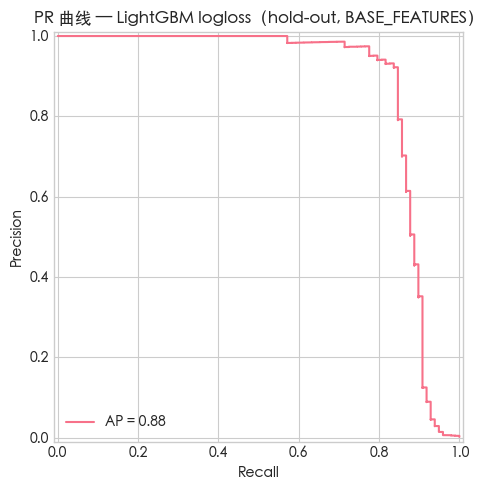

阈值扫描（LightGBM，验证集，共 104 个点）:


,阈值,F1,Precision,Recall,FP,FN,AUC-PR,备注
0,0.001,0.0825,0.0432,0.9388,2040,6,0.8767,
1,0.002,0.1339,0.0722,0.9286,1170,7,0.8767,
2,0.003,0.1748,0.0966,0.9184,842,8,0.8767,
3,0.004,0.2105,0.1189,0.9184,667,8,0.8767,
4,0.005,0.2367,0.1361,0.9082,565,9,0.8767,
...,...,...,...,...,...,...,...,...
99,0.750,0.8691,0.8925,0.8469,10,15,0.8767,
100,0.800,0.8783,0.9121,0.8469,8,15,0.8767,
101,0.850,0.8830,0.9222,0.8469,7,15,0.8767,F1最优
102,0.900,0.8757,0.9310,0.8265,6,17,0.8767,



F1 最优阈值: 0.8500  (F1=0.8830, Prec=0.9222, Rec=0.8469, FP=7, FN=15)
AUC-PR（模型级，与 threshold 无关）: 0.8767


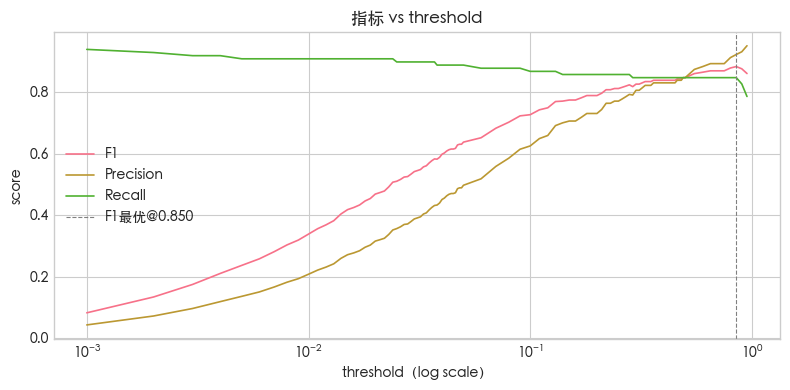

In [25]:
# --- 4.1 阈值网格搜索（2.1 logloss 验证集）---
# 依赖 2.1：BEST_MODEL_NAME, val_proba, y_val, EVAL_THRESHOLD
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, confusion_matrix

val_auc_pr = average_precision_score(y_val, val_proba)

# PR 曲线（AUC-PR 与 threshold 无关，反映模型排序能力）
prec_curve, rec_curve, _ = precision_recall_curve(y_val, val_proba)
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay(precision=prec_curve, recall=rec_curve, average_precision=val_auc_pr).plot(ax=ax)
ax.set_title(f'PR 曲线 — {BEST_MODEL_NAME} logloss（hold-out, BASE_FEATURES）')
plt.tight_layout()
plt.show()


def threshold_metrics(y_true, proba, threshold, auc_pr):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        '阈值': round(float(threshold), 4),
        'F1': f1_score(y_true, pred, zero_division=0),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'FP': fp,
        'FN': fn,
        'AUC-PR': auc_pr,
    }


# 阈值搜索：低区间更细（欺诈概率普遍偏低）
THR_GRID = np.unique(np.concatenate([
    np.linspace(0.001, 0.05, 50),
    np.linspace(0.06, 0.50, 45),
    np.linspace(0.55, 0.95, 9),
]))

thr_scan = pd.DataFrame([
    threshold_metrics(y_val, val_proba, t, val_auc_pr) for t in THR_GRID
])
best_f1_idx = thr_scan['F1'].idxmax()
thr_scan['备注'] = ''
thr_scan.loc[best_f1_idx, '备注'] = 'F1最优'
if abs(thr_scan.loc[best_f1_idx, '阈值'] - EVAL_THRESHOLD) > 1e-6:
    default_mask = np.isclose(thr_scan['阈值'], EVAL_THRESHOLD)
    if default_mask.any():
        thr_scan.loc[default_mask, '备注'] = '默认@0.5'

print(f'阈值扫描（{BEST_MODEL_NAME}，验证集，共 {len(thr_scan)} 个点）:')
display(thr_scan.round(4))

BEST_F1_THRESHOLD = float(thr_scan.loc[best_f1_idx, '阈值'])
BUSINESS_THRESHOLD = BEST_F1_THRESHOLD  # 4.2 spw 对照用
print(f'\nF1 最优阈值: {BEST_F1_THRESHOLD:.4f}  '
      f"(F1={thr_scan.loc[best_f1_idx, 'F1']:.4f}, "
      f"Prec={thr_scan.loc[best_f1_idx, 'Precision']:.4f}, "
      f"Rec={thr_scan.loc[best_f1_idx, 'Recall']:.4f}, "
      f"FP={int(thr_scan.loc[best_f1_idx, 'FP'])}, "
      f"FN={int(thr_scan.loc[best_f1_idx, 'FN'])})")
print(f'AUC-PR（模型级，与 threshold 无关）: {val_auc_pr:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_scan['阈值'], thr_scan['F1'], label='F1', lw=1.2)
ax.plot(thr_scan['阈值'], thr_scan['Precision'], label='Precision', lw=1.2)
ax.plot(thr_scan['阈值'], thr_scan['Recall'], label='Recall', lw=1.2)
ax.axvline(BEST_F1_THRESHOLD, ls='--', c='gray', lw=0.8, label=f'F1最优@{BEST_F1_THRESHOLD:.3f}')
ax.set_xscale('log')
ax.set_xlabel('threshold（log scale）')
ax.set_ylabel('score')
ax.set_title('指标 vs threshold')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [26]:
# --- 4.2 scale_pos_weight / 类别权重对比（logloss，MODEL_FEATURES）---
# 在 hold-out 上重训，对比不同 pos 权重对 FN / FP 的影响。

X_tr = df_model.loc[X_train.index, MODEL_FEATURES]
X_va = df_model.loc[X_val.index, MODEL_FEATURES]
spw_base = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

SPW_VARIANTS = {
    'default (LGB balanced / XGB spw)': None,
    'spw_sqrt': 'sqrt',
    'spw_2x': 2.0,
    'spw_0.5x': 0.5,
    'no_weight': 0.0,
}


def make_classifier_spw(model_name, y_train, variant_key, params=None):
    """logloss + 可配置 pos 权重；variant_key 见 SPW_VARIANTS。"""
    params = dict(params or {})
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    vk = SPW_VARIANTS[variant_key]

    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
        )
        if vk is None:
            defaults['class_weight'] = 'balanced'
        elif vk == 0.0:
            pass
        elif vk == 'sqrt':
            defaults['class_weight'] = {0: 1.0, 1: np.sqrt(spw)}
        else:
            defaults['class_weight'] = {0: 1.0, 1: spw * vk}
        defaults.update(params)
        return lgb.LGBMClassifier(**defaults)

    if model_name == 'XGBoost':
        if vk is None:
            xgb_spw = spw
        elif vk == 0.0:
            xgb_spw = 1.0
        elif vk == 'sqrt':
            xgb_spw = np.sqrt(spw)
        else:
            xgb_spw = spw * vk
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
            min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=xgb_spw,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=42, eval_metric='logloss', verbosity=0,
        )
        defaults.update(params)
        defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
        return xgb.XGBClassifier(**defaults)

    raise ValueError(f'未知模型: {model_name}')


def eval_spw_variant(model_name, variant_key, thresholds=(0.5, 'business')):
    X_fit, X_es, y_fit, y_es = _split_early_stop_set(X_tr, y_train, random_state=42)
    clf = make_classifier_spw(model_name, y_fit, variant_key)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    proba = clf.predict_proba(X_va)[:, 1]
    row = {
        '模型': model_name,
        '权重方案': variant_key,
        'AUC-PR': average_precision_score(y_val, proba),
    }
    for th in thresholds:
        t = BUSINESS_THRESHOLD if th == 'business' else th
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
        tag = f'@{t:.3f}' if isinstance(t, float) else str(t)
        row[f'FN{tag}'] = fn
        row[f'FP{tag}'] = fp
        row[f'Prec{tag}'] = precision_score(y_val, pred, zero_division=0)
        row[f'Rec{tag}'] = recall_score(y_val, pred, zero_division=0)
    return row


SPW_MODEL = BEST_MODEL_NAME
spw_rows = [eval_spw_variant(SPW_MODEL, vk) for vk in SPW_VARIANTS]
spw_df = pd.DataFrame(spw_rows).sort_values('AUC-PR', ascending=False)
print(f'=== spw 对比（{SPW_MODEL}, MODEL_FEATURES, logloss）===')
print(f'训练集 pos 权重基准 spw = n_neg/n_pos ≈ {spw_base:.1f}')
display(spw_df.round(4))

print('\n解读：提高 pos 权重 → 倾向多报欺诈 → FN↓ FP↑；降低则相反。')
print('阈值列含 @0.500（默认）与 @BUSINESS_THRESHOLD（4.1 F1 最优阈值）。')


=== spw 对比（LightGBM, MODEL_FEATURES, logloss）===
训练集 pos 权重基准 spw = n_neg/n_pos ≈ 577.3


,模型,权重方案,AUC-PR,FN@0.500,FP@0.500,Prec@0.500,Rec@0.500,FN@0.850,FP@0.850,Prec@0.850,Rec@0.850
0,LightGBM,default (LGB balanced / XGB spw),0.8774,15,13,0.8646,0.8469,16,8,0.9111,0.8367
2,LightGBM,spw_2x,0.8763,15,10,0.8925,0.8469,17,7,0.9205,0.8265
1,LightGBM,spw_sqrt,0.8722,16,12,0.8723,0.8367,24,5,0.9367,0.7551
3,LightGBM,spw_0.5x,0.8691,15,13,0.8646,0.8469,16,7,0.9213,0.8367
4,LightGBM,no_weight,0.8229,27,8,0.8987,0.7245,29,3,0.9583,0.7041



解读：提高 pos 权重 → 倾向多报欺诈 → FN↓ FP↑；降低则相反。
阈值列含 @0.500（默认）与 @BUSINESS_THRESHOLD（4.1 F1 最优阈值）。


总的来说还是应该做完特征工程再调参

## 5. Todo #5 — 超参搜索、融合（本notebook内弃用）

**特征集：** `MODEL_FEATURES`（V + Amount + Time + hours_since_start + is_one_euro）

**验证：** Stratified 5-fold CV，目标 **AUC-PR**；hold-out 与 2.1 同 `random_state=42` 划分。

阈值调优已前移至 **Todo #4**；本节聚焦模型能力与融合。


In [27]:
# --- 5.2 Stacking：LGB + XGB OOF 概率 + Logistic 二级融合 ---
from sklearn.linear_model import LogisticRegression

BOOST_MODELS = ['LightGBM', 'XGBoost']
X_tune = df_model.loc[X_train.index, MODEL_FEATURES]
y_tune = y_train
TUNED_PARAMS = {'LightGBM': {}, 'XGBoost': {}}  # 5.1 调参完成后可填入

oof_lgb = get_oof_proba('LightGBM', X_tune, y_tune, params=TUNED_PARAMS['LightGBM'])
oof_xgb = get_oof_proba('XGBoost', X_tune, y_tune, params=TUNED_PARAMS['XGBoost'])
oof_X = np.column_stack([oof_lgb, oof_xgb])

meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
meta.fit(oof_X, y_tune)
stack_oof_proba = meta.predict_proba(oof_X)[:, 1]
stack_cv_ap = average_precision_score(y_tune, stack_oof_proba)
print(f'Stacking OOF AUC-PR: {stack_cv_ap:.4f}')

X_tr_stack = df_model.loc[X_train.index, MODEL_FEATURES]
X_va_stack = df_model.loc[X_val.index, MODEL_FEATURES]

hold_proba = {}
for mn in BOOST_MODELS:
    X_fit, X_es, y_fit, y_es = _split_early_stop_set(X_tr_stack, y_train, random_state=42)
    c = make_classifier(mn, y_fit, params=TUNED_PARAMS[mn])
    fit_classifier(c, mn, X_fit, y_fit, X_es, y_es)
    hold_proba[mn] = c.predict_proba(X_va_stack)[:, 1]
hold_stack = meta.predict_proba(np.column_stack([
    hold_proba['LightGBM'], hold_proba['XGBoost'],
]))[:, 1]

hold_rows = []
for label, proba in [
    ('LightGBM', hold_proba['LightGBM']),
    ('XGBoost', hold_proba['XGBoost']),
    ('Stacking', hold_stack),
]:
    hold_rows.append({
        '模型': label,
        'hold-out AUC-PR': average_precision_score(y_val, proba),
    })
hold_df = pd.DataFrame(hold_rows).sort_values('hold-out AUC-PR', ascending=False)
print('\n=== hold-out 对比（logloss 默认超参）===')
display(hold_df.round(4))

FINAL_MODEL = hold_df.iloc[0]['模型']
final_hold_proba = hold_stack if FINAL_MODEL == 'Stacking' else hold_proba[FINAL_MODEL]
print(f'最终选用: {FINAL_MODEL}')
print('（业务阈值见 Todo #4 BUSINESS_THRESHOLD，可对本节 proba 再扫一遍）')


Stacking OOF AUC-PR: 0.7997

=== hold-out 对比（logloss 默认超参）===


,模型,hold-out AUC-PR
0,LightGBM,0.8774
1,XGBoost,0.8726
2,Stacking,0.7924


最终选用: LightGBM
（业务阈值见 Todo #4 BUSINESS_THRESHOLD，可对本节 proba 再扫一遍）


## 6. Todo #6 — 特征工程（定稿）

**已拆至独立 notebook：** [`credit-fraud-feature-engineering.ipynb`](credit-fraud-feature-engineering.ipynb)

内容：Family A 门控交叉 + OOF Autoencoder + `MODEL_FEATURES_V2` 定稿。下方 cell 为早期占位，可不再运行。


In [28]:
# --- 6.1 Ablation：复用 feature_ablation() ---
bool_ablation = feature_ablation(
    df_fe,
    candidate_features=FACT_BOOLS,
    model_name=ABLATION_MODEL,
)
display(bool_ablation.round(4))

cont_ablation = feature_ablation(
    df_fe,
    candidate_features=['log1p_amount', 'hours_since_start'],
    model_name=ABLATION_MODEL,
)
print('连续衍生特征 ablation:')
display(cont_ablation.round(4))


NameError: name 'df_fe' is not defined